# RAG
Retrieval Augmented Generation (RAG) is a technique that helps you work with large documents that are too big to fit into a single prompt. Instead of cramming everything into one massive prompt, RAG breaks documents into chunks and only includes the most relevant pieces when answering questions.

### The Problem with Large Documents

Imagine you have an 800-page financial document and want to ask Claude specific questions about it, like "What risk factors does this company have?" You need to get the relevant information from the document to Claude somehow, but there are limits to how much text you can include in a prompt.

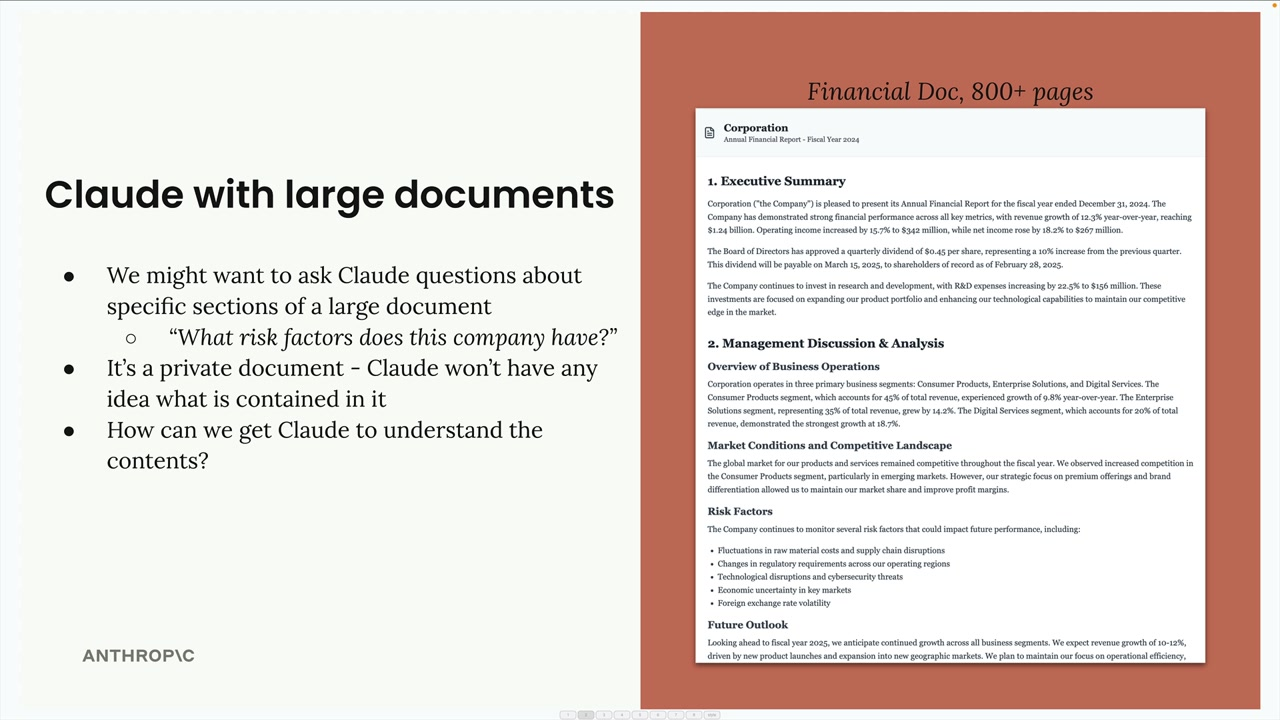



#### Option 1: Include Everything in the Prompt

The first approach is straightforward - extract all text from the document and stuff it into your prompt along with the user's question. Your prompt might look like this:

Answer the user's question about the financial document.

<user_question>
{user_question}
</user_question>

<financial_document>
{financial_document}
</financial_document>

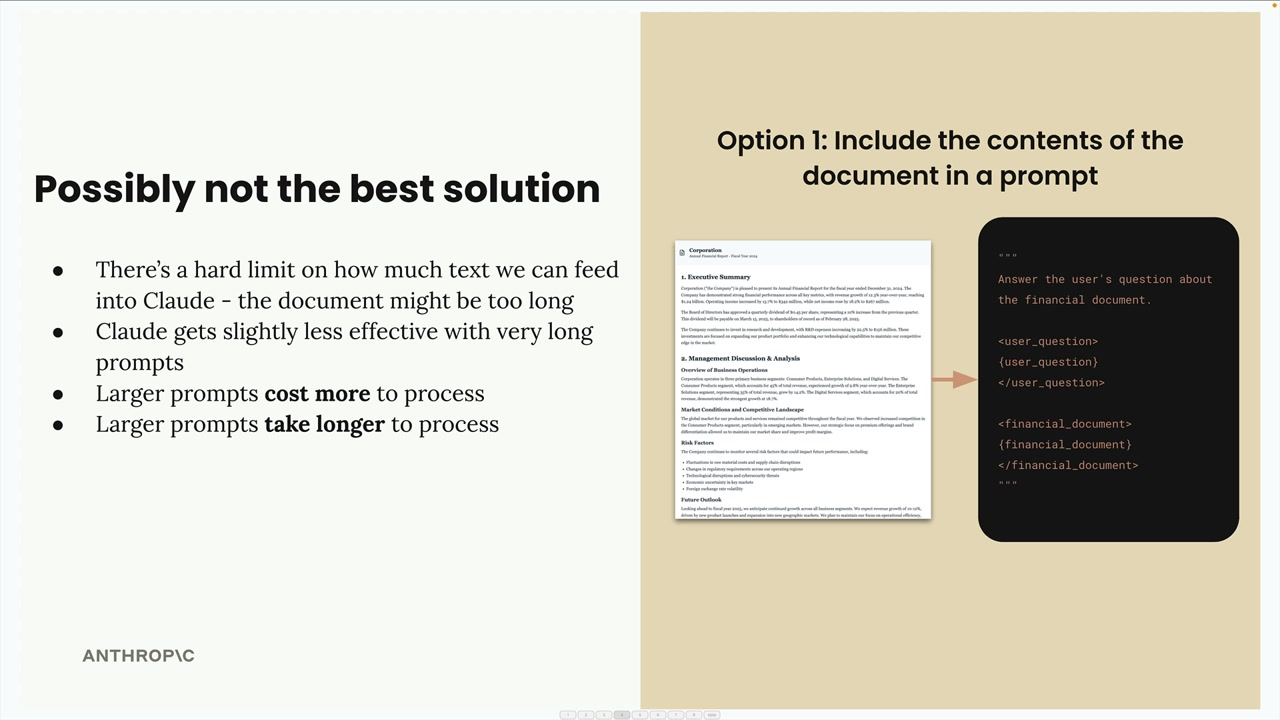



This approach has serious limitations:

    There's a hard limit on prompt length - your document might be too long
    Claude becomes less effective with very long prompts
    Larger prompts cost more to process
    Larger prompts take longer to process

####  Option 2: Break Documents into Chunks

RAG takes a smarter approach. First, you break the document into smaller chunks during a preprocessing step. Then, when a user asks a question, you find the chunks most relevant to their question and only include those in your prompt.

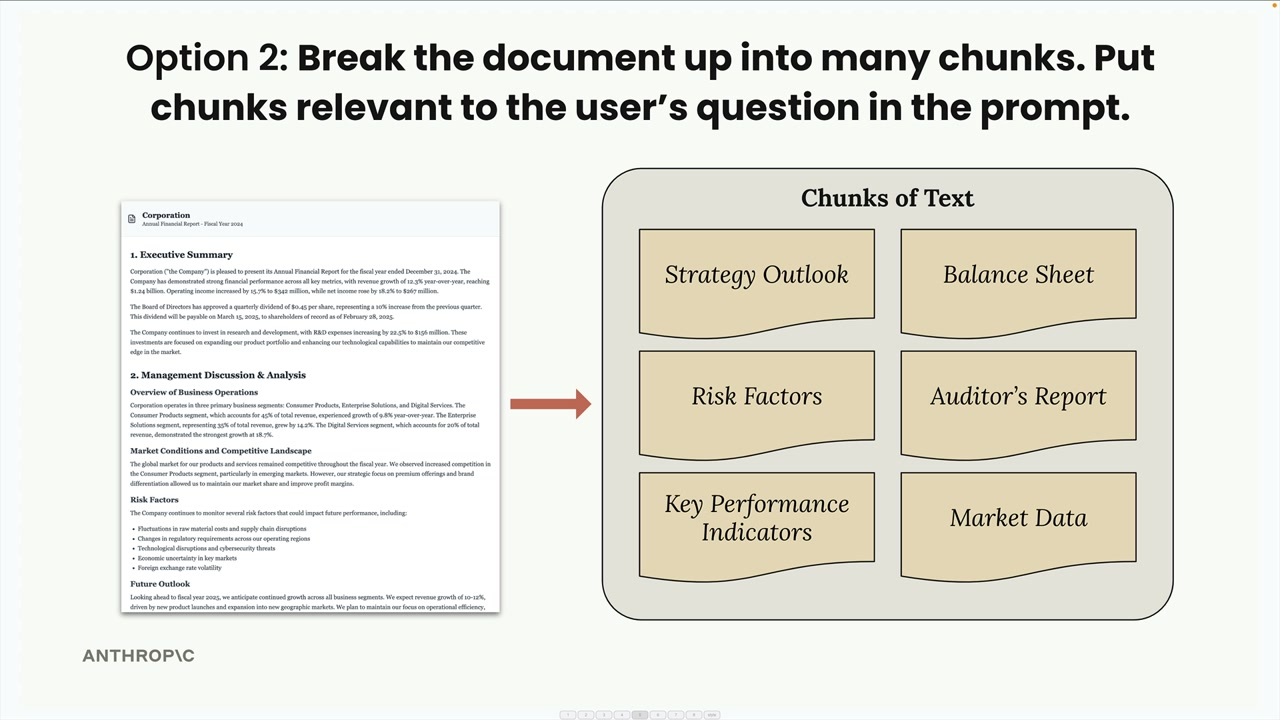


Here's how it works: if someone asks "What risks does this company face?" you'd search through your chunks, find the "Risk Factors" section, and include just that relevant chunk in your prompt.


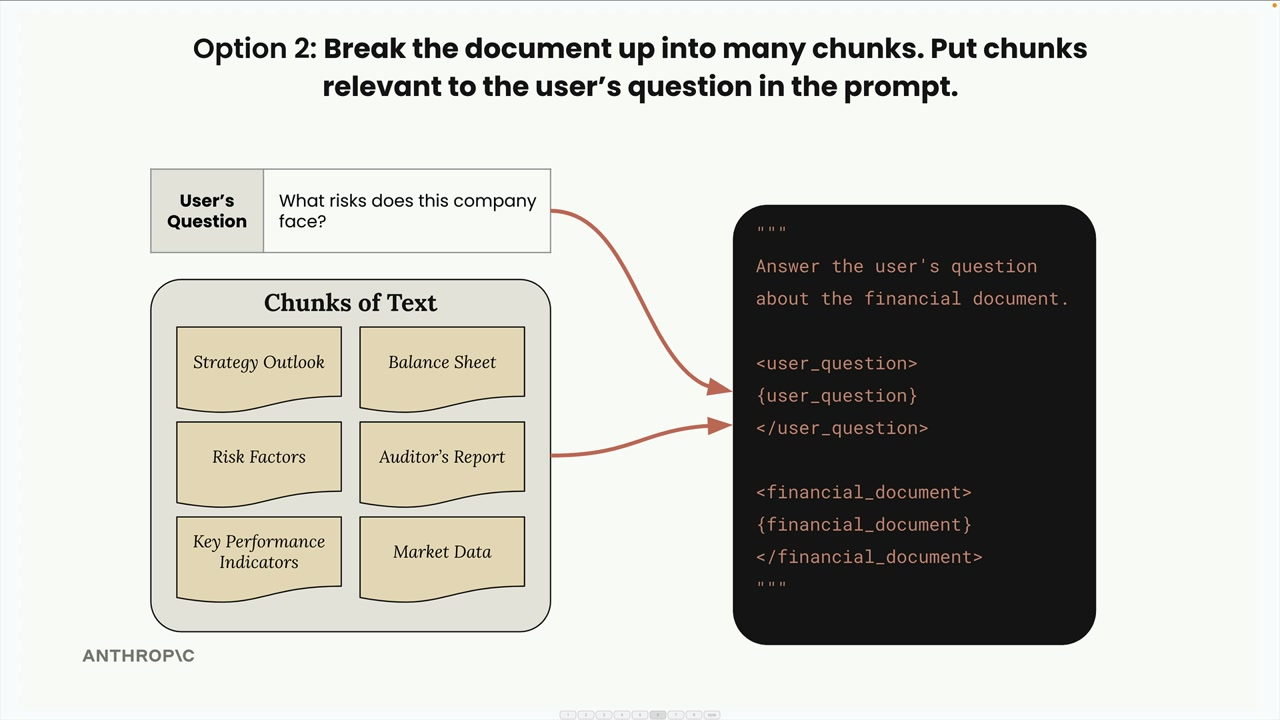


### Benefits of RAG

    Claude can focus on only the most relevant content
    Scales up to very large documents
    Works with multiple documents
    Smaller prompts cost less and run faster

### Challenges with RAG

    Requires a preprocessing step to chunk documents
    Need a search mechanism to find "relevant" chunks
    Included chunks might not contain all the context Claude needs
    Many ways to chunk text - which approach is best?

For example, you could split documents into equal-sized portions, or you could create chunks based on document structure like headers and sections. Each approach has trade-offs you'll need to evaluate for your specific use case.

### When to Use RAG

RAG involves many technical decisions and requires more work than simply including everything in a prompt. You'll need to analyze whether the benefits outweigh the complexity for your particular application. It's especially valuable when working with very large documents, multiple documents, or when you need to optimize for cost and performance.

The key insight is that RAG trades simplicity for scalability and efficiency. While it requires more upfront work to implement properly, it enables you to work with document collections that would be impossible to handle with simple prompt stuffing.

## Text Chunking

Text chunking is one of the most critical steps in building a RAG (Retrieval Augmented Generation) pipeline. How you break up your documents directly impacts the quality of your entire system. A poor chunking strategy can lead to irrelevant context being inserted into your prompts, causing your AI to give completely wrong answers.

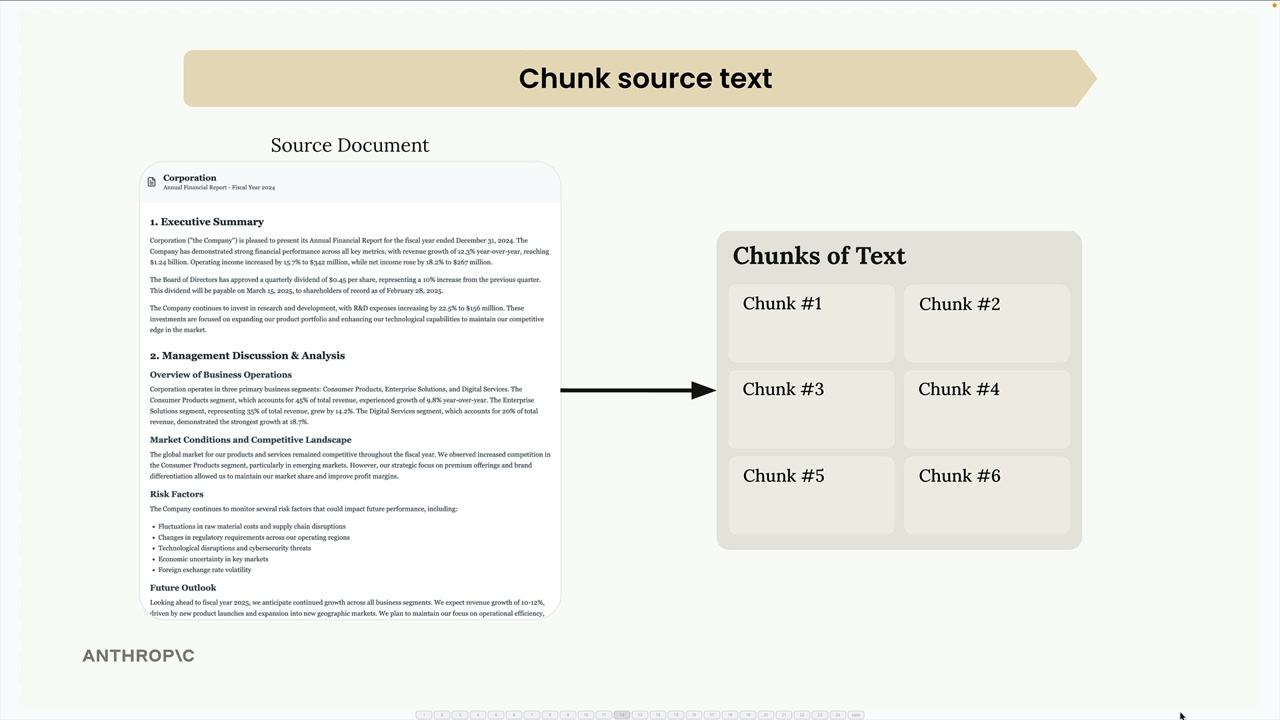


Consider this example: you have a document with sections on medical research and software engineering. If you chunk poorly, a user asking "How many bugs did engineers fix this year?" might get information about medical research instead of software engineering, simply because the medical section happened to contain the word "bug" in a different context.

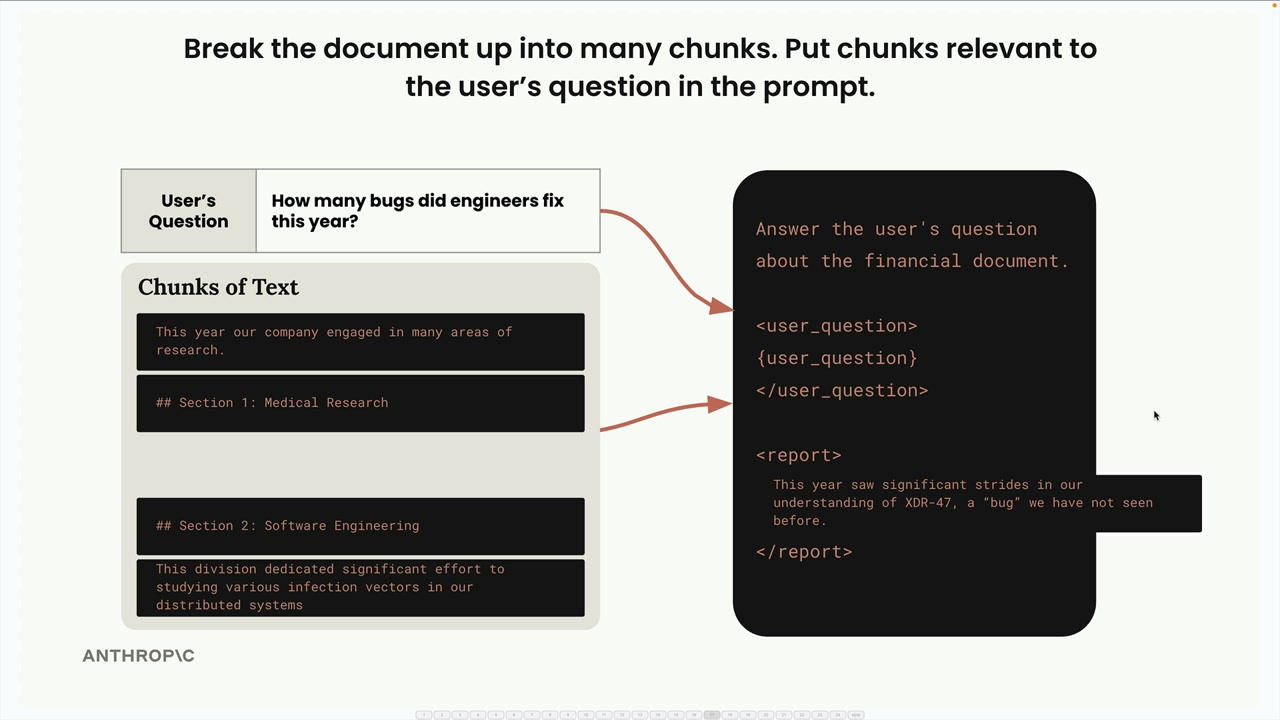


This is why choosing the right chunking strategy matters so much. Let's explore three main approaches.


### Size-Based Chunking
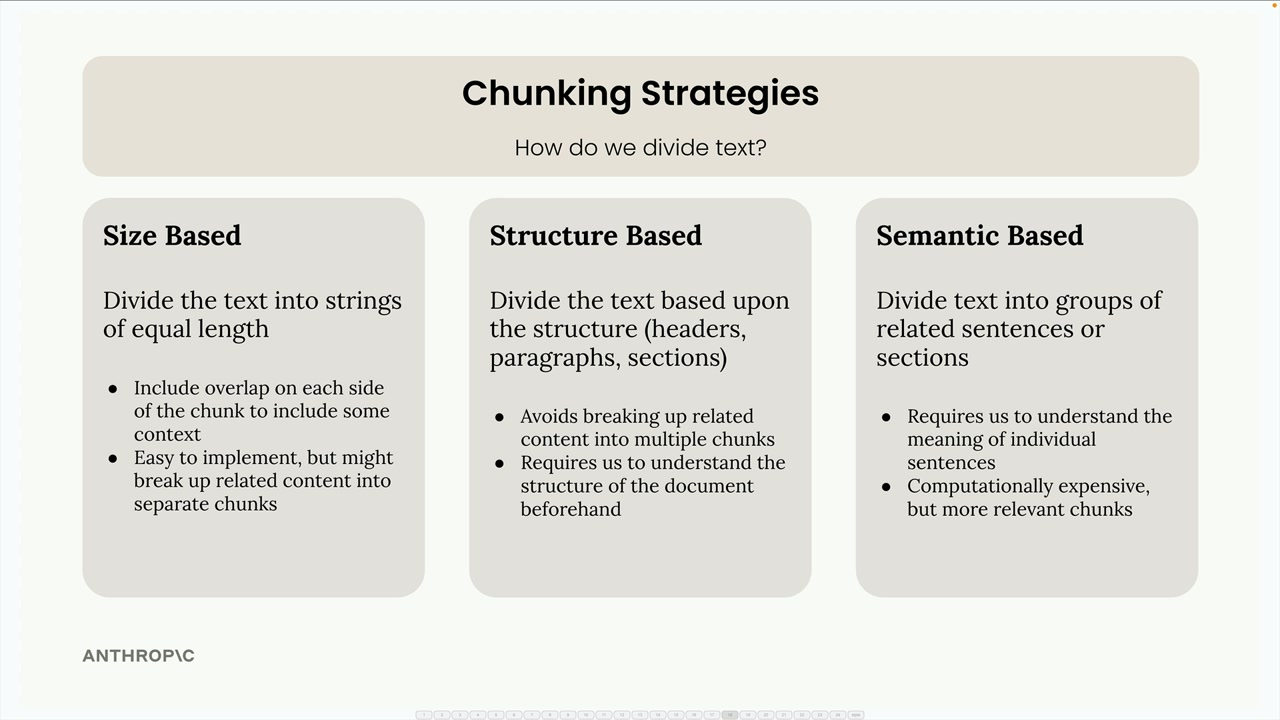

Size-based chunking is the simplest approach - you divide your text into strings of equal length. If you have a 325-character document, you might split it into three chunks of roughly 108 characters each.

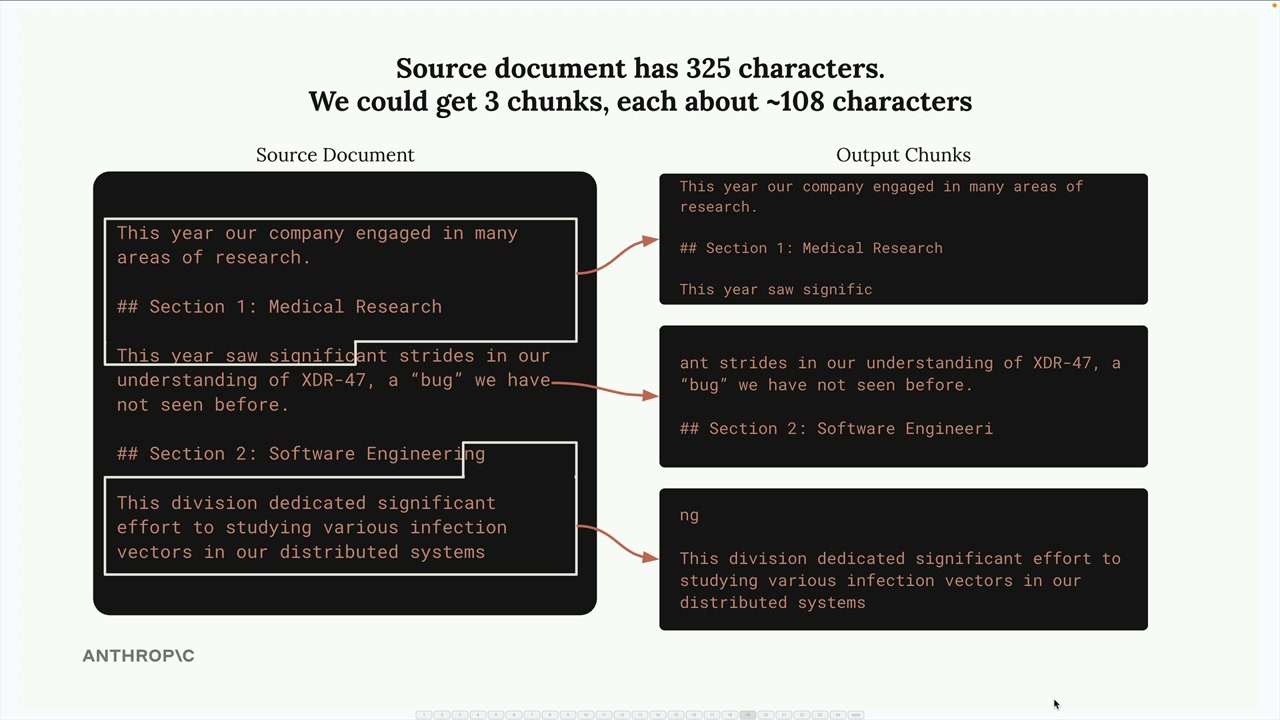

This method is easy to implement and works with any type of document, but it has clear downsides:

    Words get cut off mid-sentence
    Chunks lose important context from surrounding text
    Section headers might be separated from their content

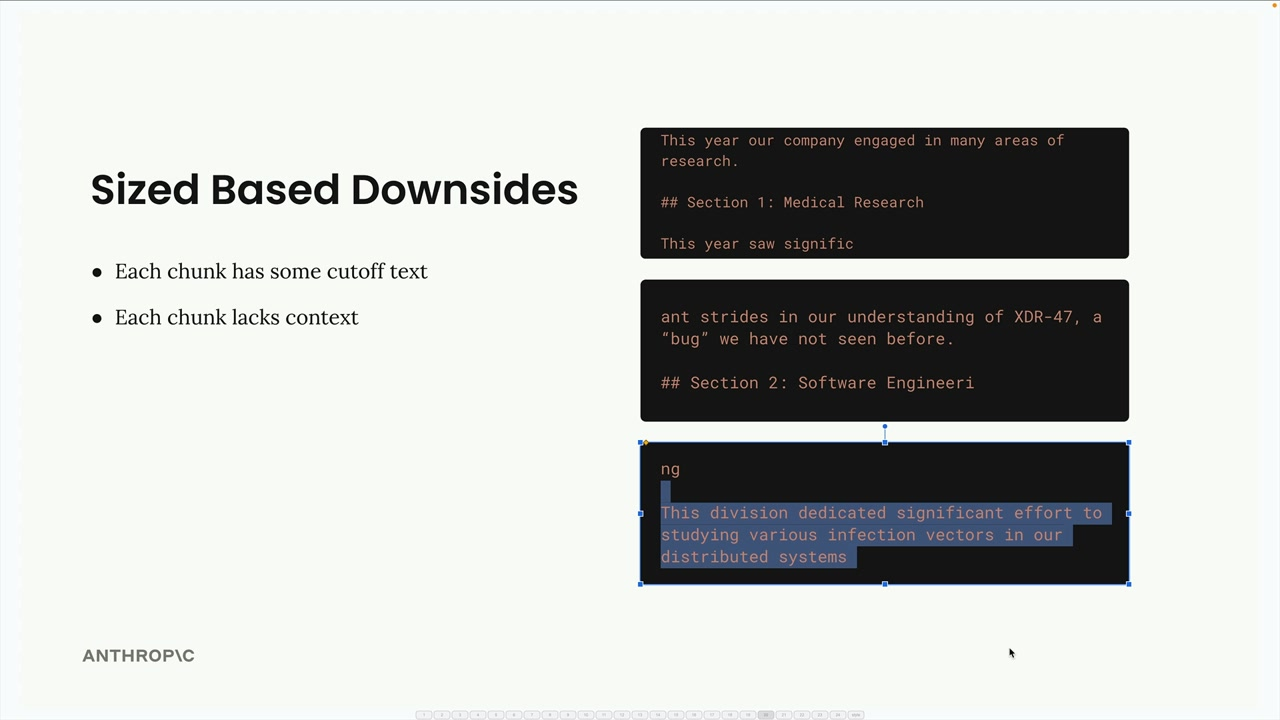

To address these issues, you can add overlap between chunks. This means each chunk includes some characters from the neighboring chunks, providing better context and ensuring complete words and sentences.

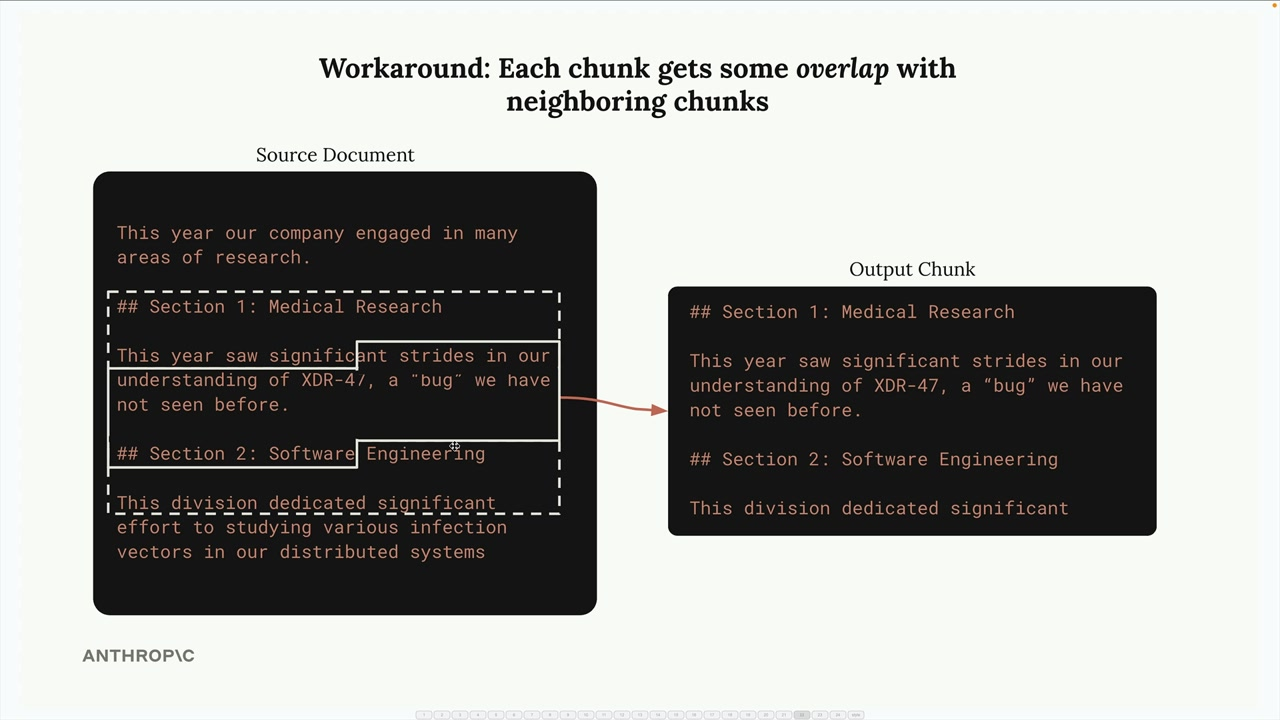


Here's a basic implementation:

```py
def chunk_by_char(text, chunk_size=150, chunk_overlap=20):
    chunks = []
    start_idx = 0
    
    while start_idx < len(text):
        end_idx = min(start_idx + chunk_size, len(text))
        chunk_text = text[start_idx:end_idx]
        chunks.append(chunk_text)
        
        start_idx = (
            end_idx - chunk_overlap if end_idx < len(text) else len(text)
        )
    
    return chunks
```

### Structure-Based Chunking

Structure-based chunking divides text based on the document's natural structure - headers, paragraphs, and sections. This works great when you have well-formatted documents like Markdown files.


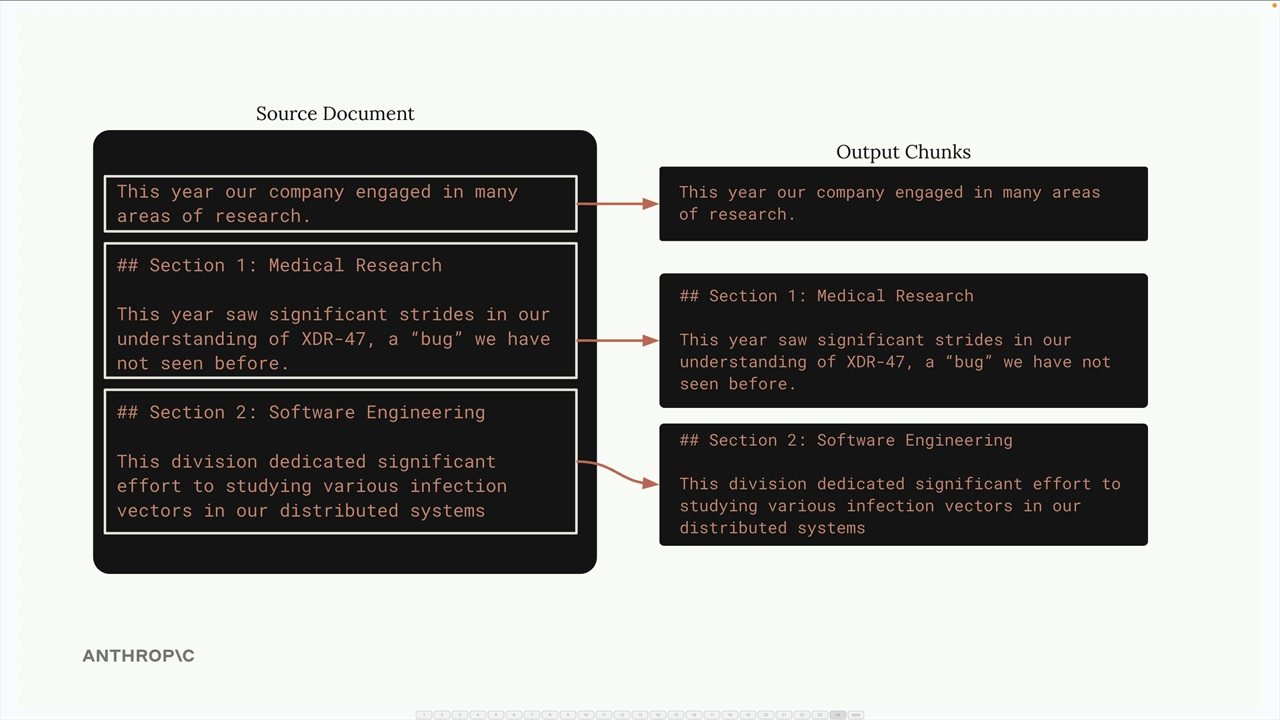

For a Markdown document, you can split on header markers:

```py
def chunk_by_section(document_text):
    pattern = r"\n## "
    return re.split(pattern, document_text)
```

This approach gives you the cleanest, most meaningful chunks because each one represents a complete section. However, it only works when you have guarantees about your document structure. Many real-world documents are plain text or PDFs without clear structural markers.

### Semantic-Based Chunking

Semantic-based chunking is the most sophisticated approach. You divide text into sentences, then use natural language processing to determine how related consecutive sentences are. You build chunks from groups of related sentences.

This method is computationally expensive but produces the most relevant chunks. It requires understanding the meaning of individual sentences and is more complex to implement than the other strategies.
Sentence-Based Chunking

A practical middle ground is chunking by sentences. You split the text into individual sentences using regular expressions, then group them into chunks with optional overlap:

```py
def chunk_by_sentence(text, max_sentences_per_chunk=5, overlap_sentences=1):
    sentences = re.split(r"(?<=[.!?])\s+", text)
    
    chunks = []
    start_idx = 0
    
    while start_idx < len(sentences):
        end_idx = min(start_idx + max_sentences_per_chunk, len(sentences))
        current_chunk = sentences[start_idx:end_idx]
        chunks.append(" ".join(current_chunk))
        
        start_idx += max_sentences_per_chunk - overlap_sentences
        
        if start_idx < 0:
            start_idx = 0
    
    return chunks
```

### Choosing Your Strategy

Your choice depends entirely on your use case and document guarantees:

    Structure-based: Best results when you control document formatting (like internal company reports)
    Sentence-based: Good middle ground for most text documents
    Size-based: Most reliable fallback that works with any content type, including code

Size-based chunking with overlap is often the go-to choice in production because it's simple, reliable, and works with any document type. While it may not give perfect results, it consistently produces reasonable chunks that won't break your pipeline.

Remember: there's no single "best" chunking strategy. The right approach depends on your specific documents, use cases, and the trade-offs you're willing to make between implementation complexity and chunk quality.



## Text Embedding

After breaking a document into chunks, the next step in a RAG pipeline is finding which chunks are most relevant to a user's question. This is essentially a search problem - you need to look through all your text chunks and identify the ones that relate to what the user is asking about.

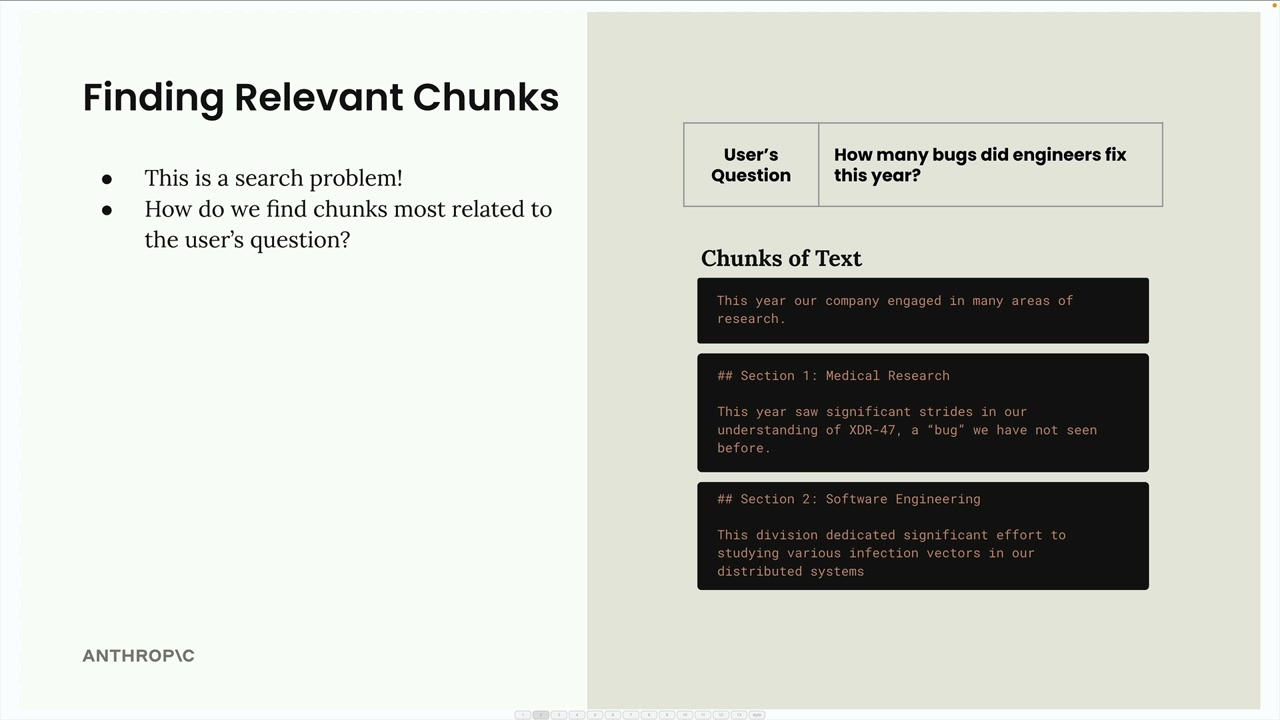


Semantic Search

The most common approach for finding relevant chunks is semantic search. Unlike keyword-based search that looks for exact word matches, semantic search uses text embeddings to understand the meaning and context of both the user's question and each text chunk.


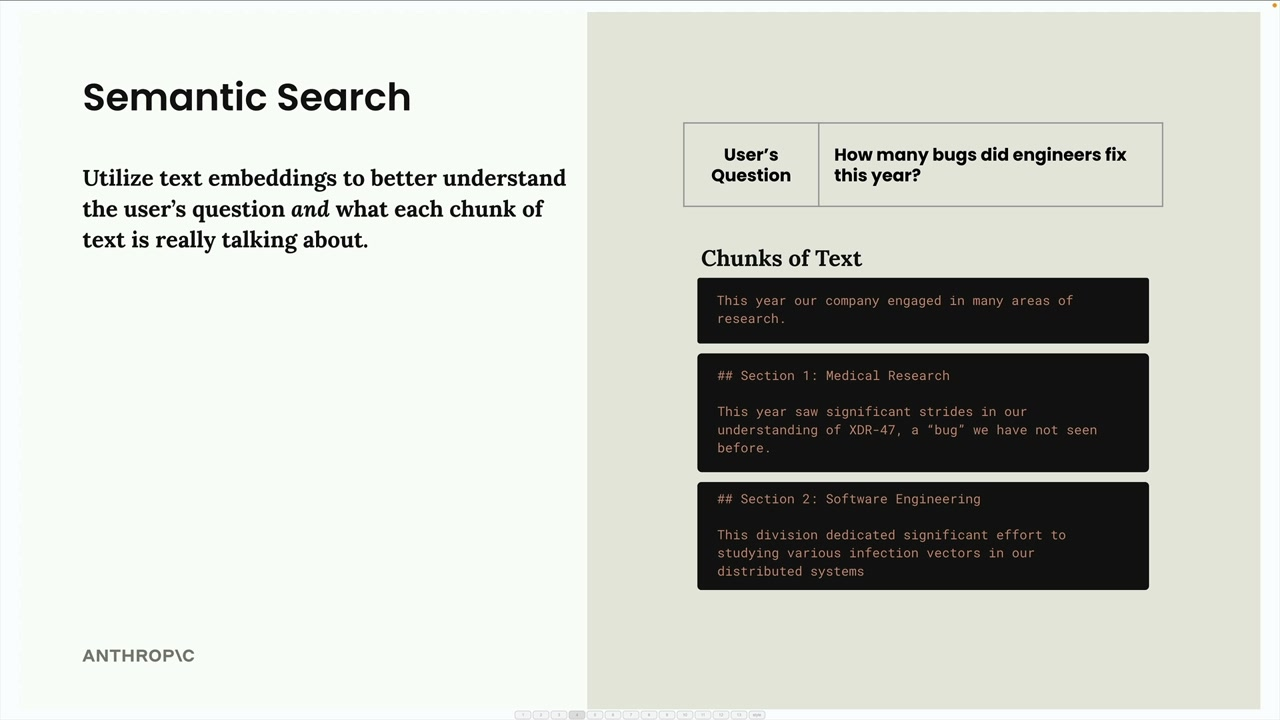

Text Embeddings

A text embedding is a numerical representation of the meaning contained in some text. Think of it as converting words and sentences into a format that computers can work with mathematically.

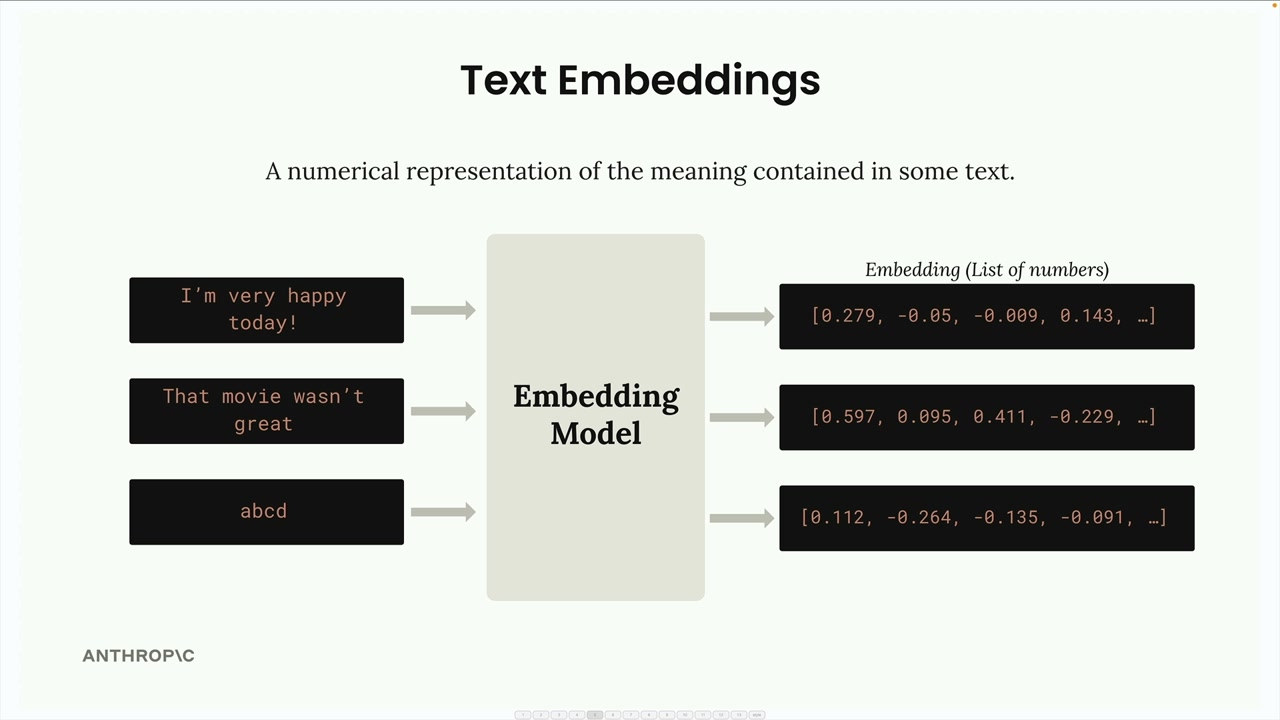

Here's how the process works:

    You feed text into an embedding model
    The model outputs a long list of numbers (the embedding)
    Each number ranges from -1 to +1
    These numbers represent different qualities or features of the input text

Understanding the Numbers

Each number in an embedding is essentially a "score" for some quality of the input text. However, here's the important caveat: we don't know precisely what each number represents.


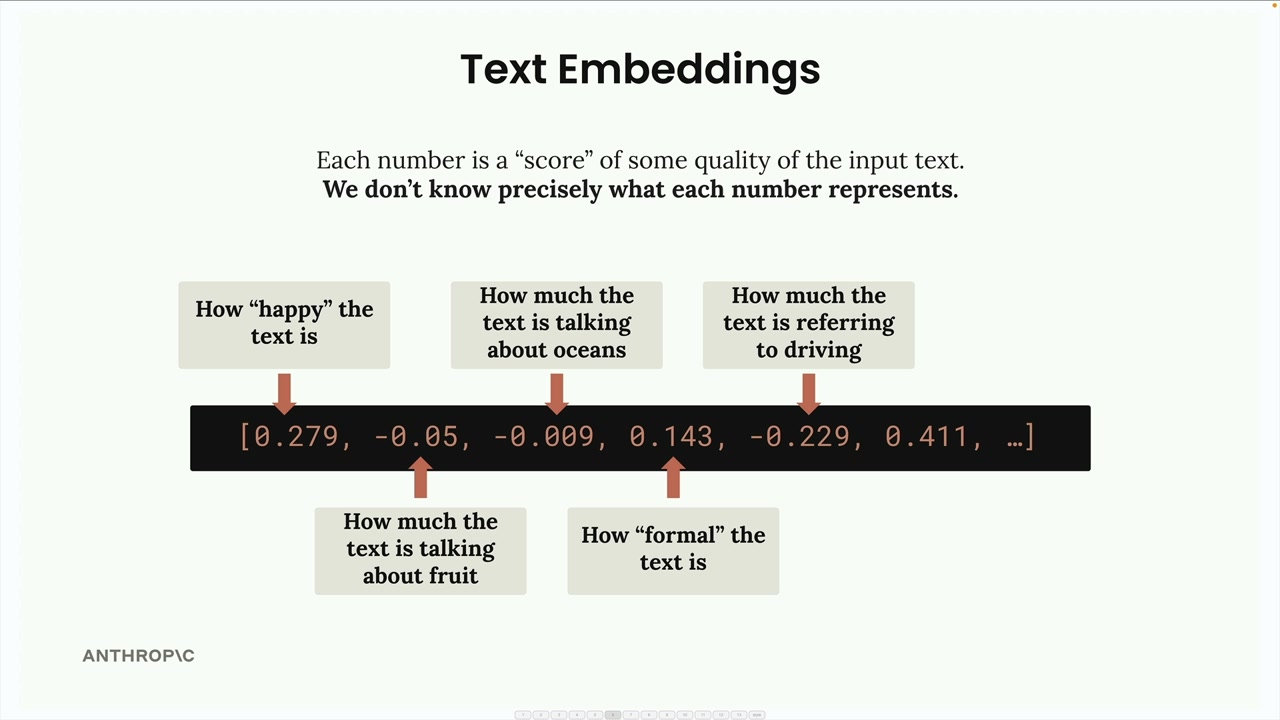


While it's helpful to imagine that one number might represent "how happy the text is" or "how much the text talks about oceans," these are just conceptual examples. The actual meaning of each dimension is learned by the model during training and isn't directly interpretable by humans.
VoyageAI for Embeddings

Since Anthropic doesn't currently provide embedding generation, the recommended provider is VoyageAI. You'll need to:

    Sign up for a separate VoyageAI account
    Get an API key (free to get started)
    Add the key to your environment variables


In your .env file, add:

```
VOYAGE_API_KEY="your_key_here"
```

Implementation

First, install the VoyageAI library:

```
%pip install voyageai
```

Then set up the client and create a function to generate embeddings:

```py
from dotenv import load_dotenv
import voyageai

load_dotenv()
client = voyageai.Client()

def generate_embedding(text, model="voyage-3-large", input_type="query"):
    result = client.embed([text], model=model, input_type=input_type)
    return result.embeddings[0]
```


When you run this function on a text chunk, you'll get back a list of floating-point numbers representing the embedding. The process is quick and straightforward - the real challenge is understanding how to use these embeddings effectively in your RAG pipeline for finding the most relevant content.

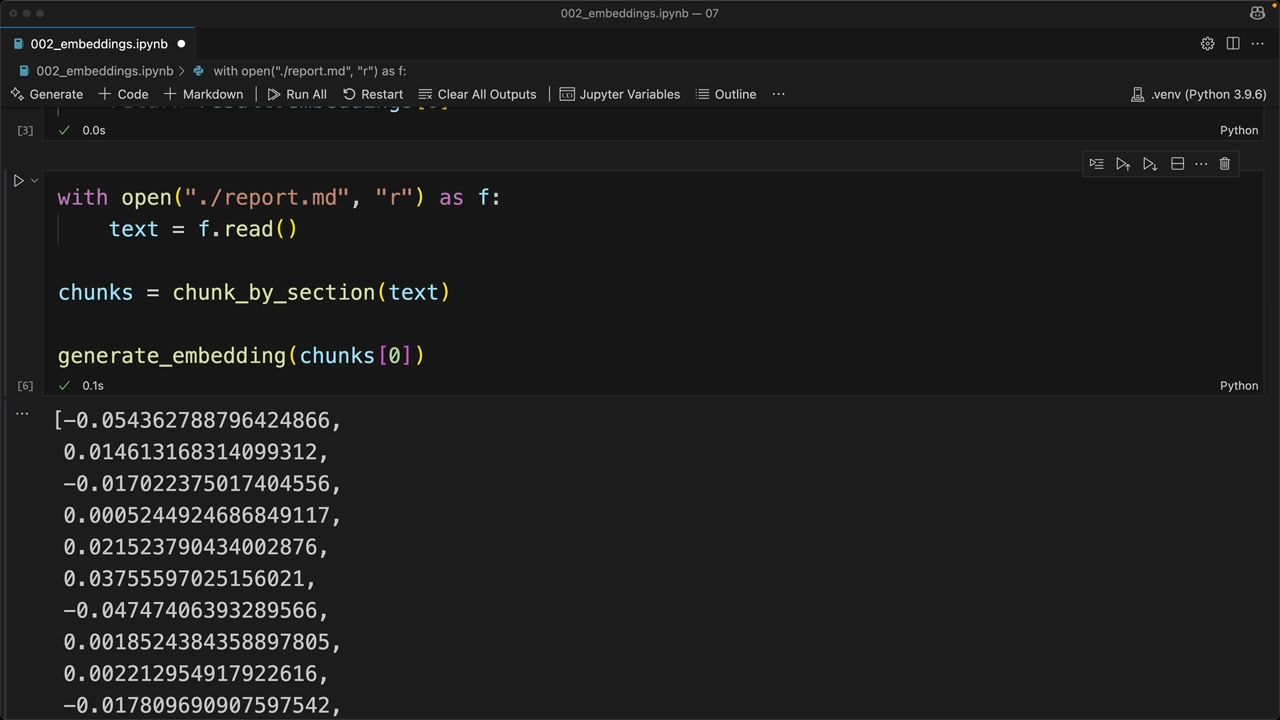

The next step is learning how to compare embeddings to determine which chunks are most similar to a user's question, which forms the core of the semantic search process.